In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
summary_table = pd.read_csv("summary_table.csv")
summary_table


,Unnamed: 0,Beauty_minor,Beauty_adult,Fitness_minor,Fitness_adult,Gaming_minor,Gaming_adult
0,Age,16,21,17,20,16,21
1,Age_Group,Minor,Adult,Minor,Adult,Minor,Adult
2,Gender,female,female,male,male,female,female
3,Interest,beauty,beauty,fitness,fitness,gaming,gaming
4,Total Records,651,1088,876,2341,868,1271
5,Non Ad Records,482,842,831,1807,817,970
6,Ads Detected,169,246,45,534,51,301
7,Average Video Length,54.78,35.6,35.78,13.94,29.94,29.95
8,Other Ads,140,232,44,223,39,73
9,Other Ads Topic: beauty,129,146,3,11,2,0


In [3]:
agents_mapping = {
    "Beauty_minor": "Beauty Minor",
    "Beauty_adult": "Beauty Adult",
    "Fitness_minor": "Fitness Minor",
    "Fitness_adult": "Fitness Adult",
    "Gaming_minor": "Gaming Minor",
    "Gaming_adult": "Gaming Adult",
}

In [4]:
ad_types_mapping = {
    "all": "all types",
    "formal": "Formal",
    "influencer": "Disclosed",
    "other": "Undisclosed",
}

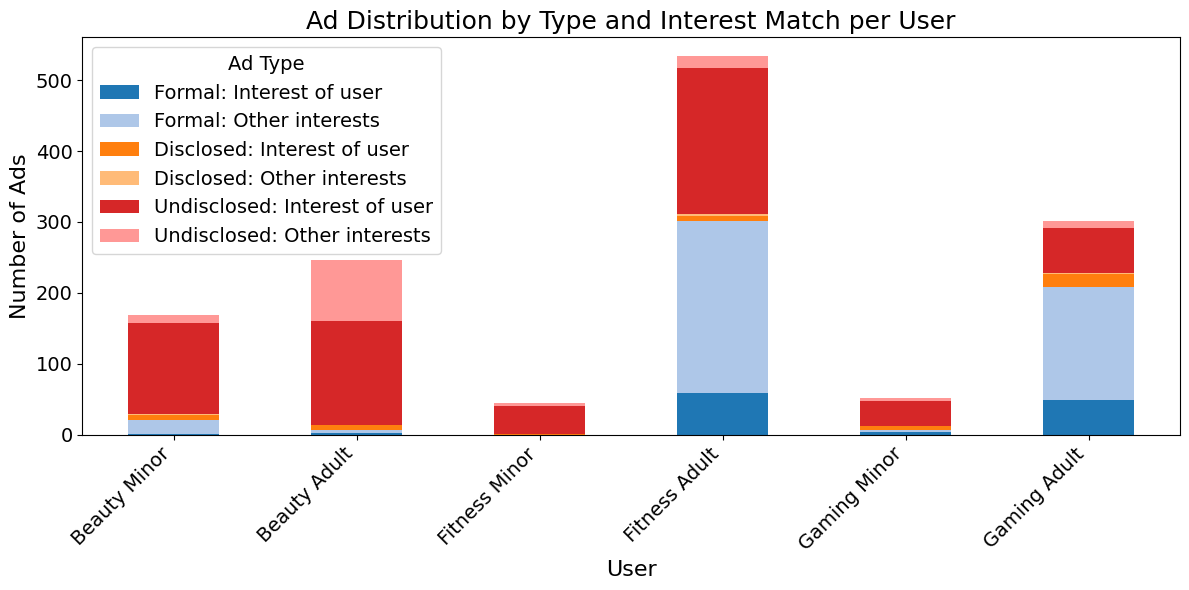

In [6]:
# Prepare data for stacked bar chart split by interest match
agents = summary_table.columns[1:]

# Extract interest from agent mapping
def get_interest(agent_label):
    return agent_label.split(' ')[0].lower()

ad_data_rows = []
for i, agent in enumerate(agents):
    agent_label = agents_mapping[agent]
    interest = get_interest(agent_label)

    # For each ad type, split into matching and non-matching interest
    formal_match = float(summary_table.loc[summary_table.iloc[:, 0] == f'Formal Ads Topic: {interest}'].values[0][i+1])
    formal_topics = ['beauty', 'fitness', 'gaming', 'other']
    formal_nomatch = sum([
        float(summary_table.loc[summary_table.iloc[:, 0] == f'Formal Ads Topic: {topic}'].values[0][i+1])
        for topic in formal_topics if topic != interest
    ])
    
    influencer_match = float(summary_table.loc[summary_table.iloc[:, 0] == f'Influencer Ads Topic: {interest}'].values[0][i+1])
    influencer_nomatch = sum([
        float(summary_table.loc[summary_table.iloc[:, 0] == f'Influencer Ads Topic: {topic}'].values[0][i+1])
        for topic in formal_topics if topic != interest
    ])
    
    other_match = float(summary_table.loc[summary_table.iloc[:, 0] == f'Other Ads Topic: {interest}'].values[0][i+1])
    other_nomatch = sum([
        float(summary_table.loc[summary_table.iloc[:, 0] == f'Other Ads Topic: {topic}'].values[0][i+1])
        for topic in formal_topics if topic != interest
    ])
    
    ad_data_rows.append({
        'Agent': agent_label,
        f'{ad_types_mapping["formal"]}: Interest of user': formal_match,
        f'{ad_types_mapping["formal"]}: Other interests': formal_nomatch,
        f'{ad_types_mapping["influencer"]}: Interest of user': influencer_match,
        f'{ad_types_mapping["influencer"]}: Other interests': influencer_nomatch,
        f'{ad_types_mapping["other"]}: Interest of user': other_match,
        f'{ad_types_mapping["other"]}: Other interests': other_nomatch
    })

ad_data = pd.DataFrame(ad_data_rows)

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))
ad_data.set_index('Agent')[[f'{ad_types_mapping["formal"]}: Interest of user', f'{ad_types_mapping["formal"]}: Other interests', 
                              f'{ad_types_mapping["influencer"]}: Interest of user', f'{ad_types_mapping["influencer"]}: Other interests',
                              f'{ad_types_mapping["other"]}: Interest of user', f'{ad_types_mapping["other"]}: Other interests']].plot(
    kind='bar', 
    stacked=True, 
    ax=ax,
    color=['#1f77b4', '#aec7e8','#ff7f0e', '#ffbb78', '#d62728', '#ff9896']
)
ax.set_ylabel('Number of Ads', fontsize=16)
ax.set_xlabel('User', fontsize=16)
ax.set_title('Ad Distribution by Type and Interest Match per User', fontsize=18)
ax.legend(title='Ad Type', loc='upper left', fontsize=14, title_fontsize=14)
ax.tick_params(axis='both', labelsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
agent_metadata = pd.read_csv("agent_metadata.csv")
agent_metadata.sort_values(by=["Interest","Age_Group"], ascending=False, inplace=True)
agent_metadata.reset_index(drop=True, inplace=True)
agent_metadata

,agent,Age,Age_Group,Interest,Gender
0,Gaming_minor,16,Minor,gaming,female
1,Gaming_adult,21,Adult,gaming,female
2,Fitness_minor,17,Minor,fitness,male
3,Fitness_adult,20,Adult,fitness,male
4,Beauty_minor,16,Minor,beauty,female
5,Beauty_adult,21,Adult,beauty,female


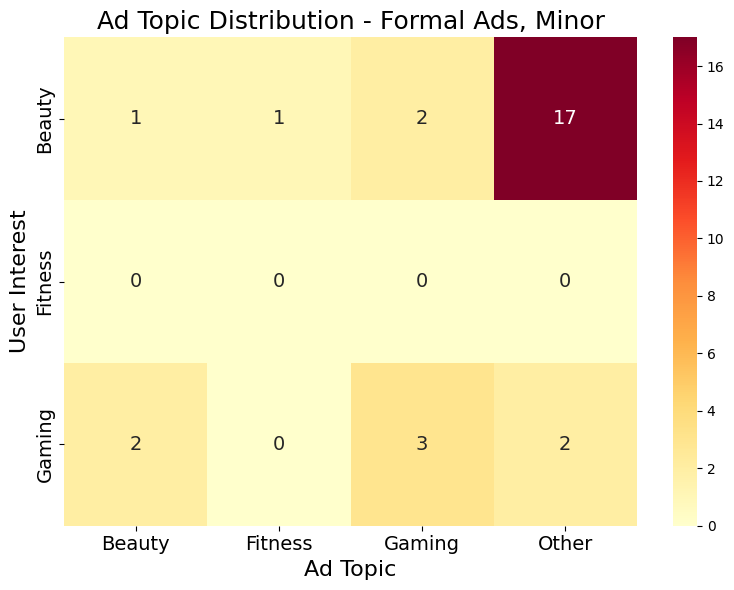

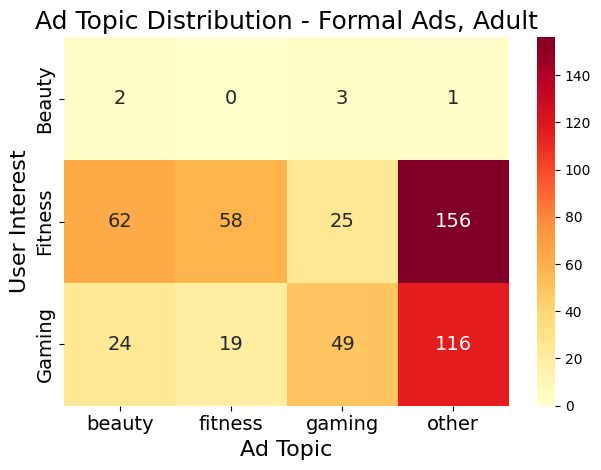

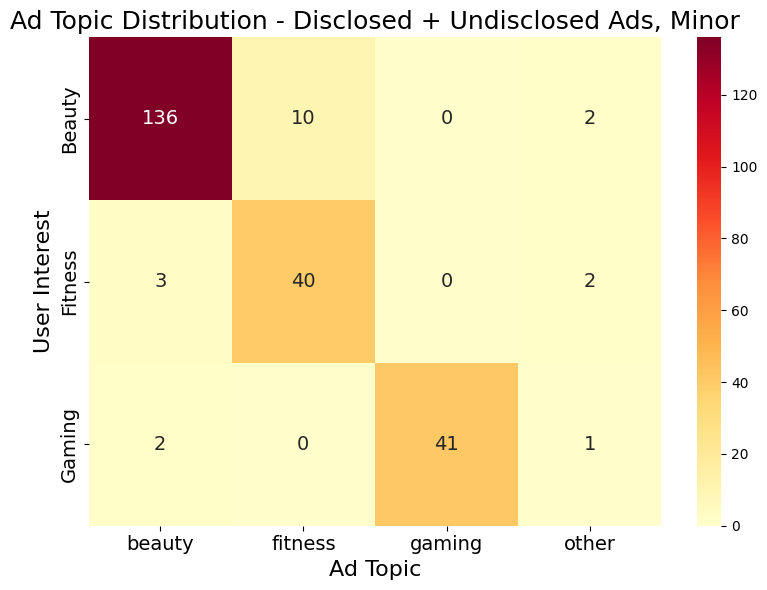

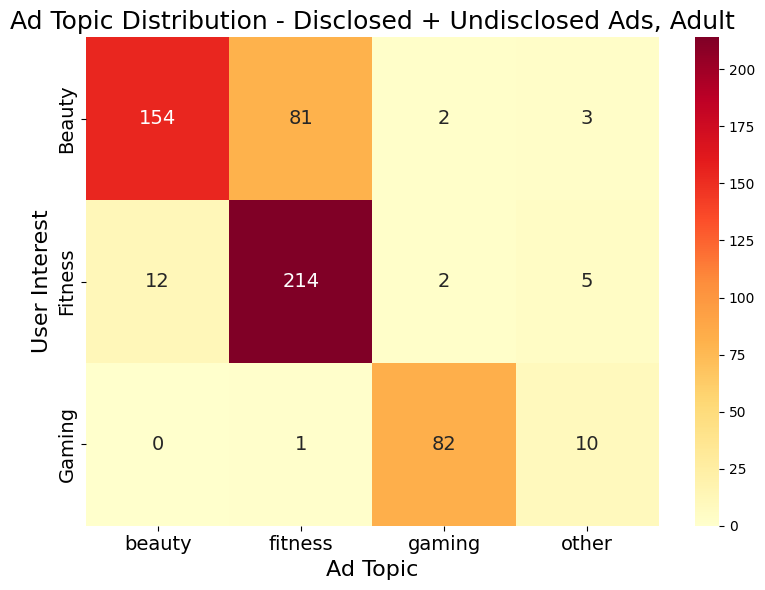

In [9]:
# Create 4 specific heatmaps: Formal (Minor/Adult) and Influencer+Other (Minor/Adult)

# 1. Formal - Minor
topic_comparison_formal = pd.read_csv("topic_comparison_table_formal.csv")
subset = topic_comparison_formal[topic_comparison_formal["Age_Group"] == "Minor"][["Interest", "beauty", "fitness", "gaming", "other"]]
subset[["beauty", "fitness", "gaming", "other"]] = subset[["beauty", "fitness", "gaming", "other"]].astype(int)
subset.set_index("Interest", inplace=True)

# Ensure all interests are present (beauty, fitness, gaming), fill missing with 0
all_interests = ['beauty', 'fitness', 'gaming']
subset = subset.reindex(all_interests, fill_value=0)

# Capitalize column names and index
subset.columns = [col.capitalize() for col in subset.columns]
subset.index = [idx.capitalize() for idx in subset.index]

plt.figure(figsize=(8, 6))
sns.heatmap(subset, annot=True, fmt='d', cmap='YlOrRd', annot_kws={'fontsize': 14})
plt.title(f'Ad Topic Distribution - {ad_types_mapping["formal"]} Ads, Minor', fontsize=18)
plt.xlabel('Ad Topic', fontsize=16)
plt.ylabel('User Interest', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

# 2. Formal - Adult
subset = topic_comparison_formal[topic_comparison_formal["Age_Group"] == "Adult"][["Interest", "beauty", "fitness", "gaming", "other"]]
subset[["beauty", "fitness", "gaming", "other"]] = subset[["beauty", "fitness", "gaming", "other"]].astype(int)
subset.set_index("Interest", inplace=True)

# Ensure all interests are present (beauty, fitness, gaming), fill missing with 0
subset = subset.reindex(all_interests, fill_value=0)
# Capitalize column names and index
# Capitalize column names
subset.index = [idx.capitalize() for idx in subset.index]
sns.heatmap(subset, annot=True, fmt='d', cmap='YlOrRd', annot_kws={'fontsize': 14})
plt.title(f'Ad Topic Distribution - {ad_types_mapping["formal"]} Ads, Adult', fontsize=18)
plt.xlabel('Ad Topic', fontsize=16)
plt.ylabel('User Interest', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

# 3 & 4. Influencer + Other combined
topic_comparison_influencer = pd.read_csv("topic_comparison_table_influencer.csv")
topic_comparison_other = pd.read_csv("topic_comparison_table_other.csv")

# Combine influencer and other ad counts
combined_data = []
for demographics in ["Minor", "Adult"]:
    subset_inf = topic_comparison_influencer[topic_comparison_influencer["Age_Group"] == demographics][["Interest", "beauty", "fitness", "gaming", "other"]]
    subset_oth = topic_comparison_other[topic_comparison_other["Age_Group"] == demographics][["Interest", "beauty", "fitness", "gaming", "other"]]
    
    # Ensure both have the same index
    subset_inf.set_index("Interest", inplace=True)
    subset_oth.set_index("Interest", inplace=True)
    
    # Reindex to ensure all interests present
    subset_inf = subset_inf.reindex(all_interests, fill_value=0)
    subset_oth = subset_oth.reindex(all_interests, fill_value=0)
    
    # Sum the counts
    subset_combined = subset_inf[["beauty", "fitness", "gaming", "other"]].values + subset_oth[["beauty", "fitness", "gaming", "other"]].values
    subset_combined = pd.DataFrame(subset_combined, index=all_interests, columns=["beauty", "fitness", "gaming", "other"])
    # Capitalize column names and index
    # Capitalize column names
    subset_combined.index = [idx.capitalize() for idx in subset_combined.index]
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(subset_combined, annot=True, fmt='d', cmap='YlOrRd', annot_kws={'fontsize': 14})
    plt.title(f'Ad Topic Distribution - {ad_types_mapping["influencer"]} + {ad_types_mapping["other"]} Ads, {demographics}', fontsize=18)
    plt.xlabel('Ad Topic', fontsize=16)
    plt.ylabel('User Interest', fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()

    plt.show()